<a href="https://colab.research.google.com/github/Atharv-Chopade/Deep-Learning/blob/main/DL_Day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [52]:
from sklearn.datasets import load_wine
wine = load_wine()
X = wine.data
y = wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
lr = [0.1 , 0.01 , 0.001]
batch = [8 , 16 , 32]
epochs = [10 , 30 , 100]

In [54]:
final = {
    'lr' : [],
    'batch' : [],
    'epochs' : [],
    'accuracy' : [],
    'loss' : []
}

In [55]:
from tensorflow.keras.optimizers import Adam

In [56]:
model = Sequential()
model.add(Dense(16 , activation = 'relu' ))
model.add(Dense(8 , activation='relu'))
model.add(Dense(1 , activation='sigmoid'))

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
for l in lr:
    for b in batch:
        for e in epochs:
          adam = Adam(learning_rate= l)
          model.compile(optimizer = adam, loss = 'binary_crossentropy' , metrics = ['accuracy'])
          model.fit(X_train , y_train , batch_size = b , epochs = e,validation_data=(X_test,y_test))
          loss , accuracy = model.evaluate(X_test , y_test)
          final['lr'].append(l)
          final['batch'].append(b)
          final['epochs'].append(e)
          final['accuracy'].append(accuracy)
          final['loss'].append(loss)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6620 - loss: -124.0380 - val_accuracy: 0.7500 - val_loss: -421.9271
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6549 - loss: -1942.8108 - val_accuracy: 0.7500 - val_loss: -4762.6270
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6127 - loss: -13430.0537 - val_accuracy: 0.7500 - val_loss: -24259.0762
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6197 - loss: -56933.1562 - val_accuracy: 0.7778 - val_loss: -79272.2656
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6479 - loss: -149812.0938 - val_accuracy: 0.7778 - val_loss: -199177.5938
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6690 - loss: -364351.3125 - val_accuracy: 0.7778 - val_loss: -394213.1250
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6549 - loss: -666034.3125 - val_accuracy: 0.7778 - val_loss: -685878.1250
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms

In [59]:
final = pd.DataFrame(final)

In [60]:
final

,lr,batch,epochs,accuracy,loss
0,0.100,8,10,0.722222,-2.596899e+06
1,0.100,8,30,0.777778,-1.340698e+08
2,0.100,8,100,0.750000,-4.576660e+09
3,0.100,16,10,0.777778,-4.952656e+09
4,0.100,16,30,0.777778,-6.232962e+09
5,0.100,16,100,0.777778,-1.247791e+10
6,0.100,32,10,0.777778,-1.288288e+10
7,0.100,32,30,0.777778,-1.419633e+10
8,0.100,32,100,0.777778,-1.930249e+10
9,0.010,8,10,0.777778,-1.947578e+10


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='epochs', ylabel='accuracy'>

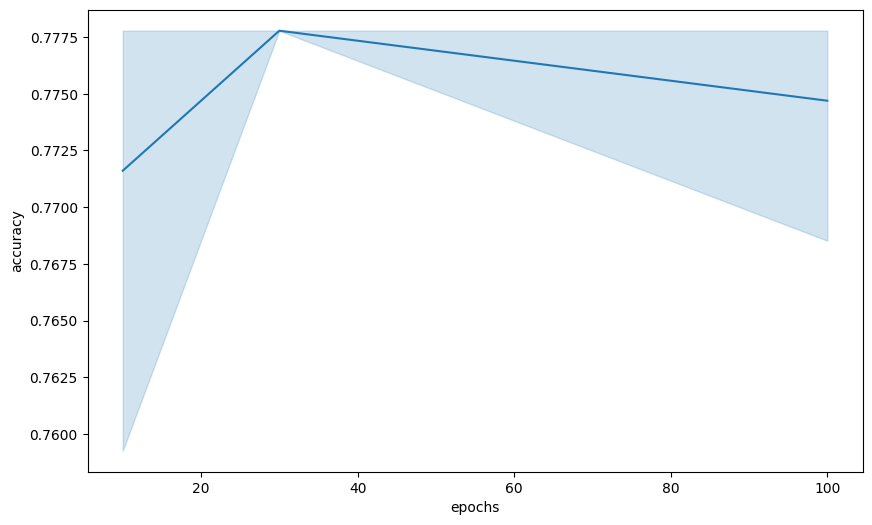

In [62]:
plt.figure(figsize=(10,6))
sns.lineplot(x='epochs' , y='accuracy' , data=final)

<Axes: xlabel='epochs', ylabel='loss'>

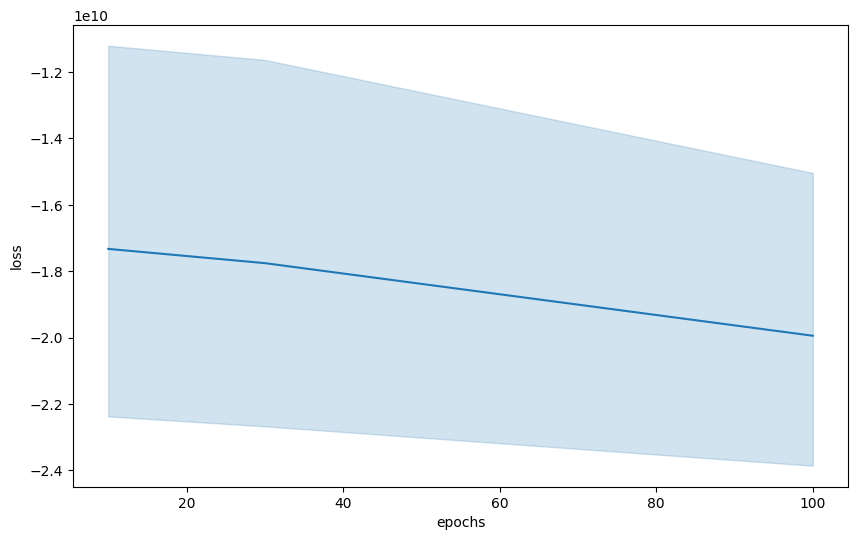

In [63]:
plt.figure(figsize=(10,6))
sns.lineplot(x='epochs' , y='loss' , data=final)